In [96]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from typing import TypedDict, Literal, Annotated, Any
from dotenv import load_dotenv
from uuid import uuid4
import operator

load_dotenv()

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [97]:
DEFAULT_MAX_RETRIES = 2

In [98]:
AgentType = Literal["research", "data", "writing"]
SubtaskStatus = Literal["pending", "running", "passed", "failed", "escalated"]
WorkflowStatus = Literal[
    "initialised",
    "planning",
    "executing",
    "reviewing",
    "completed",
    "failed",
    "escalated",
]

In [99]:
class Subtask(TypedDict):
    id: str
    agent_type: AgentType
    objective: str
    expected_output: str
    tools_allowed: list[str]
    review_criteria: list[str]
    status: SubtaskStatus
    retry_count: int

class SubtaskResult(TypedDict):
    subtask_id: str
    agent_type: AgentType
    output: Any
    confidence: float
    sources: list[dict]
    errors: list[str]

class ReviewReport(TypedDict):
    subtask_id: str
    passed: bool
    score: float
    issues: list[str]
    action: Literal["pass", "retry", "reassign", "escalate"]


class FinalReview(TypedDict):
    passed: bool
    score: float
    issues: list[str]
    action: Literal["return", "retry", "replan", "escalate"]

In [100]:
class SupervisorState(TypedDict, total=False):
    # Request identity
    task_id: str
    user_id: str
    user_request: str

    # Workflow status
    status: WorkflowStatus
    error: str | None

    # Planning
    plan: dict
    plan_confidence: float
    subtasks: list[Subtask]

    # Current execution pointer
    current_subtask_id: str | None

    # Specialist outputs
    subtask_results: dict[str, SubtaskResult]

    # Reviews
    review_reports: Annotated[list[ReviewReport], operator.add]
    final_review: FinalReview | None

    # Retry / escalation
    max_retries: int
    escalation_reason: str | None

    # Final response
    final_answer: str | None

In [101]:
from pydantic import BaseModel, Field, ConfigDict, model_validator

class PlannedSubtaskSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    agent_type: AgentType = Field(description="The specialist agent type that should handle this subtask.")
    objective: str = Field(
        description="A clear, specific instruction describing what this specialist must accomplish for this subtask."
    )
    expected_output: str = Field(
        description="The expected deliverable from this subtask, including the desired format or contents where relevant."
    )
    review_criteria: list[str] = Field(
        default_factory=list,
        description="A checklist the reviewer should use to judge whether this subtask was completed successfully."
    )

class SupervisorPlanSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    plan: str = Field(
        description=(
            "A concise high-level execution plan for completing the user request. "
            "Describe the overall approach, not runtime details like ids, retries, "
            "statuses, or tool permissions."
        ),
    )

    plan_confidence: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Confidence that the plan is suitable for the user request. "
            "Use 0.0 for no confidence and 1.0 for very high confidence."
        ),
    )

    subtasks: list[PlannedSubtaskSchema] = Field(
        min_length=1,
        description=(
            "Ordered subtasks to execute sequentially. "
            "The graph will run these in the given order."
        ),
    )

class ReviewDecisionSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    passed: bool = Field(
        description=(
            "Whether the specialist output satisfies the subtask objective, "
            "expected output, and review criteria."
        )
    )

    score: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Quality score for the specialist output. "
            "Use 0.0 for unusable output and 1.0 for excellent output."
        ),
    )

    issues: list[str] = Field(
        default_factory=list,
        description=(
            "Specific problems found during review. "
            "Leave empty only if the output passes without concerns."
        ),
    )

    action: Literal["pass", "retry", "reassign", "escalate"] = Field(
        description=(
            "The next action for this subtask. "
            "Use 'pass' if the result is acceptable, 'retry' if the same specialist "
            "should try again, 'reassign' if a different specialist should handle it, "
            "or 'escalate' if human review is needed."
        )
    )

    @model_validator(mode="after")
    def validate_action_matches_passed(self) -> "ReviewDecisionSchema":
        if self.passed and self.action != "pass":
            raise ValueError("A passed review must use action='pass'.")

        if not self.passed and self.action == "pass":
            raise ValueError("A failed review cannot use action='pass'.")

        return self

class WritingResponseSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    content: str = Field(
        min_length=20,
        description=(
            "The user-facing contentanswer produced by the writing agent. "
            "It should satisfy the writing subtask objective and use the approved "
            "previous subtask results."
        ),
    )

    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Confidence in the quality and completeness of the content. "
            "Use 0.0 for no confidence and 1.0 for very high confidence."
        ),
    )

class ResearchResponseSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    summary: str = Field(
        description="Concise summary of the research findings.",
    )

    findings: list[str] = Field(
        description="Important findings relevant to the research subtask.",
    )

    uncertainties: list[str] = Field(
        default_factory=list,
        description="Known gaps, caveats, or uncertainty in the research.",
    )

    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description="Confidence in the quality and completeness of the research.",
    )

class DataResponseSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    content: str = Field(
        description=(
            "Structured analysis produced by the data agent. "
            "It should satisfy the current data subtask using the provided research context."
        ),
    )

    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Confidence in the quality and completeness of the analysis. "
            "Use 0.0 for no confidence and 1.0 for very high confidence."
        ),
    )

class SearchQuerySchema(BaseModel):
    """
    LLM output for a search provider query.

    The program validates length and passes the query to the search adapter.
    """

    model_config = ConfigDict(extra="forbid")

    query: str = Field(
        min_length=5,
        max_length=380,
        description=(
            "A concise web search query for the research subtask. "
            "It must be specific, provider-safe, and under 380 characters."
        ),
    )

class FinalReviewSchema(BaseModel):
    model_config = ConfigDict(extra="forbid")

    passed: bool = Field(
        description="Whether the complete workflow result is ready to return to the user."
    )

    score: float = Field(
        ge=0.0,
        le=1.0,
        description="Overall quality score for the complete workflow result.",
    )

    issues: list[str] = Field(
        default_factory=list,
        description="Specific problems with the complete workflow result.",
    )

    action: Literal["return", "retry", "replan", "escalate"] = Field(
        description="Next workflow action. Use return, retry, replan, or escalate."
    )

    @model_validator(mode="after")
    def validate_action_matches_passed(self) -> "FinalReviewSchema":
        if self.passed and self.action != "return":
            raise ValueError("A passed final review must use action='return'.")

        if not self.passed and self.action == "return":
            raise ValueError("A failed final review cannot use action='return'.")

        return self

In [102]:
import os
from tavily import TavilyClient


def search_web(query: str) -> list[dict[str, str]]:
    api_key = os.getenv("TAVILY_API_KEY")

    if not api_key:
        raise RuntimeError("Missing TAVILY_API_KEY environment variable.")

    client = TavilyClient(api_key=api_key)

    response = client.search(
        query=query,
        search_depth="basic",
        max_results=5,
        include_answer=False,
        include_raw_content=False,
    )

    results = response.get("results", [])

    normalised_results: list[dict[str, str]] = []

    for result in results:
        normalised_results.append(
            {
                "title": result.get("title", ""),
                "url": result.get("url", ""),
                "snippet": result.get("content", ""),
            }
        )

    return normalised_results

In [103]:
# Helpers

def get_current_subtask(state: SupervisorState) -> Subtask | None:
    current_id = state.get("current_subtask_id")
    if not current_id:
        return None

    for subtask in state.get("subtasks", []):
        if subtask["id"] == current_id:
            return subtask

    return None

def update_subtask(
    state: SupervisorState,
    subtask_id: str,
    **updates,
) -> list[Subtask]:
    updated_subtasks: list[Subtask] = []

    for subtask in state.get("subtasks", []):
        if subtask["id"] == subtask_id:
            updated_subtasks.append({**subtask, **updates})
        else:
            updated_subtasks.append(subtask)

    return updated_subtasks

def all_subtasks_passed(state: SupervisorState) -> bool:
    subtasks = state.get("subtasks", [])

    if not subtasks:
        return False

    return all(subtask.get("status") == "passed" for subtask in subtasks)


In [104]:
def format_search_results_for_research(search_results: list[dict[str, str]]) -> str:
    if not search_results:
        return "No search results were found."

    sections: list[str] = []

    for index, result in enumerate(search_results, start=1):
        title = result.get("title", "Untitled result")
        url = result.get("url", "No URL provided")
        snippet = result.get("snippet", "No snippet provided")

        sections.append(
            f"""
Result {index}
Title: {title}
URL: {url}
Snippet: {snippet}
""".strip()
        )

    return "\n\n".join(sections)

In [105]:
def format_research_context_for_data(state: SupervisorState) -> str:
    current_subtask_id = state.get("current_subtask_id")
    subtasks = state.get("subtasks", [])
    results = state.get("subtask_results", {})

    current_index: int | None = None

    for index, subtask in enumerate(subtasks):
        if subtask["id"] == current_subtask_id:
            current_index = index
            break

    if current_index is None:
        return "No passed research context was available."

    sections: list[str] = []

    for subtask in subtasks[:current_index]:
        subtask_id = subtask["id"]

        if subtask.get("status") != "passed":
            continue

        if subtask.get("agent_type") != "research":
            continue

        result = results.get(subtask_id)

        if result is None:
            continue

        if result.get("errors"):
            continue

        output = result.get("output", {})

        summary = output.get("summary")
        findings = output.get("findings", [])
        uncertainties = output.get("uncertainties", [])

        section_parts: list[str] = []

        if summary:
            section_parts.append(f"Summary:\n{summary}")

        if findings:
            finding_lines = [
                f"- {finding}"
                for finding in findings
            ]
            section_parts.append("Findings:\n" + "\n".join(finding_lines))

        if uncertainties:
            uncertainty_lines = [
                f"- {uncertainty}"
                for uncertainty in uncertainties
            ]
            section_parts.append("Uncertainties:\n" + "\n".join(uncertainty_lines))

        sources = result.get("sources", [])

        if sources:
            source_lines = []

            for source in sources:
                title = source.get("title", "Untitled source")
                url = source.get("url", "No URL")
                snippet = source.get("snippet", "")

                source_lines.append(
                    f"- {title}\n  URL: {url}\n  Snippet: {snippet}"
                )

            section_parts.append("Sources:\n" + "\n".join(source_lines))

        if section_parts:
            sections.append("\n\n".join(section_parts))

    if not sections:
        return "No passed research context was available."

    return "\n\n".join(sections)

def format_data_subtask_brief(subtask: Subtask) -> str:
    review_criteria = subtask.get("review_criteria", [])

    criteria_text = "\n".join(
        f"- {criterion}"
        for criterion in review_criteria
    )

    if not criteria_text:
        criteria_text = "- No specific review criteria provided."

    return f"""
Objective:
{subtask["objective"]}

Expected output:
{subtask["expected_output"]}

Review criteria:
{criteria_text}
""".strip()

In [106]:
TOOLS_BY_AGENT_TYPE: dict[AgentType, list[str]] = {
    "research": ["web_search"],
    "data": [],
    "writing": [],
}

In [107]:
def build_runtime_subtasks(
    planned_subtasks: list[PlannedSubtaskSchema],
) -> list[Subtask]:
    subtasks: list[Subtask] = []

    for index, planned_subtask in enumerate(planned_subtasks, start=1):
        subtasks.append(
            {
                "id": f"s{index}",
                "agent_type": planned_subtask.agent_type,
                "objective": planned_subtask.objective,
                "expected_output": planned_subtask.expected_output,
                "tools_allowed": TOOLS_BY_AGENT_TYPE[planned_subtask.agent_type],
                "review_criteria": planned_subtask.review_criteria,
                "status": "pending",
                "retry_count": 0,
            }
        )

    return subtasks

In [108]:
SUPERVISOR_SYSTEM_PROMPT = """
You are the supervisor in a multi-agent workflow.

Your job is to create a simple sequential execution plan.

Available specialist agents:
- research: gathers facts, source material, or context
- data: structures, compares, calculates, or analyses provided information
- writing: produces the final user-facing answer

Rules:
- Produce only subtasks that are necessary.
- Keep the plan sequential.
- Do not include runtime fields such as ids, statuses, retry counts, or tool permissions.
- Do not invent tools.
- If research is needed, use a research subtask before data or writing.
- If the answer needs synthesis, include a writing subtask at the end.
- Each subtask must have clear review criteria.
- If the user request is too ambiguous to complete reliably, return a low confidence score.
- For competitor research, the request must specify the company, product, market, or industry being compared.
- Do not invent the target company, market, or industry.
""".strip()

REVIEWER_SYSTEM_PROMPT = """
You are the reviewer in a multi-agent workflow.

Your job is to evaluate one specialist's subtask output.

You must judge the output against:
- the subtask objective
- the expected output
- the review criteria
- any errors in the specialist result
- the specialist confidence score

Rules:
- Use action='pass' only if the output satisfies the subtask requirements.
- Use action='retry' if the same specialist should try again.
- Use action='reassign' if the work appears better suited to a different specialist.
- Use action='escalate' if the result is unsafe, too uncertain, or cannot be fixed automatically.
- If passed is true, action must be 'pass'.
- If passed is false, action must not be 'pass'.
- Be strict about missing required output.
""".strip()

WRITING_SYSTEM_PROMPT = """
You are the writing specialist in a multi-agent workflow.

Your job is to produce user-facing content for the current writing subtask.

Use only:
- the user request
- the current writing subtask
- the provided upstream specialist context, if any

The upstream specialist context may contain passed research or data outputs.
Do not use previous writing outputs.

Rules:
- Satisfy the current subtask objective.
- Produce the expected output requested by the subtask.
- Do not invent facts that are not present in the user request or upstream specialist context.
- Clearly mark assumptions or uncertainty.
- Write in a clear, useful style for the end user.
- Do not include runtime details such as subtask ids, statuses, retries, or graph state.
""".strip()

SEARCH_QUERY_SYSTEM_PROMPT = """
You generate concise web search queries for a research agent.

Your job is to convert the user request and current research subtask into one search query.

Rules:
- Return one search query only.
- The query must be under 380 characters.
- Preserve the user's domain, market, company, product, location, timeframe, and comparison target when provided.
- Do not add a company, industry, location, or timeframe that the user did not provide.
- Remove workflow words such as research, gather, write, compare, analyse, produce, expected output, and subtask.
- Prefer concrete searchable nouns over instructions.
- Include important qualifiers such as features, pricing, competitors, reviews, alternatives, market, or buyer type when they are relevant.
""".strip()

RESEARCH_SYSTEM_PROMPT = """
You are the research specialist in a multi-agent workflow.

Your job is to produce source-grounded research notes for the current research subtask.

Use only:
- the user request
- the current research subtask
- the provided search results

Rules:
- Do not invent facts.
- Use the search results as the evidence base.
- If the search results are weak, incomplete, or irrelevant, say so.
- Clearly mark uncertainty.
- Produce concise research notes that later data and writing agents can use.
- Do not include runtime details such as subtask ids, statuses, retries, or graph state.
""".strip()

DATA_SYSTEM_PROMPT = """
You are the data specialist in a multi-agent workflow.

Your job is to analyse and structure information for the current data subtask.

Use only:
- the user request
- the current data subtask
- the provided passed research context

Rules:
- Satisfy the current data subtask objective.
- Produce the expected output requested by the subtask.
- Do not invent facts that are not present in the research context.
- Do not infer pricing, market position, feature strength, or target audience beyond what the research context states.
- If information is missing, say "not stated" or mark it as uncertain.
- Clearly compare the relevant items when the subtask asks for comparison.
- Clearly mark assumptions or uncertainty.
- Write structured, useful analysis that a writing specialist can use later.
- Do not include runtime details such as subtask ids, statuses, retries, or graph state.
""".strip()

FINAL_REVIEW_SYSTEM_PROMPT = """
You are the final reviewer in a multi-agent workflow.

Your job is to review only the final writing output.

You must decide whether the provided writing output is ready to return to the user as a final answer.

Rules:
- Review only the writing output provided to you.
- Do not ask for or assume access to the plan, subtasks, research output, data output, review reports, tools, or graph state.
- Use action='return' only if the writing output is clear, coherent, useful, and safe to return.
- Use action='retry' if the writing output is unclear, incomplete, badly structured, or needs rewriting.
- Use action='escalate' if the writing output contains unsafe content, serious unsupported claims, or cannot be judged reliably.
- Use action='replan' only if the writing output itself clearly shows the workflow misunderstood the task.
- If passed is true, action must be 'return'.
- If passed is false, action must not be 'return'.
""".strip()

In [ ]:
# Parent nodes

def initialise_task(state: SupervisorState) -> SupervisorState:
    return {
        "task_id": str(uuid4()),
        "user_id": state.get("user_id"),
        "user_request": state["user_request"],
        "status": "initialised",
        "error": None,
        "plan": "",
        "plan_confidence": 0.0,
        "subtasks": [],
        "current_subtask_id": None,
        "subtask_results": {},
        "review_reports": [],
        "final_review": None,
        "max_retries": DEFAULT_MAX_RETRIES,
        "escalation_reason": None,
        "final_answer": None,
    }

def supervisor_plan(state: SupervisorState) -> SupervisorState:
    supervisor_llm = llm.with_structured_output(SupervisorPlanSchema)

    user_request = state.get("user_request")

    if not user_request:
        return {
            "status": "failed",
            "error": "Missing required field: user_request",
            "plan": "",
            "plan_confidence": 0.0,
            "subtasks": [],
            "final_answer": None,
        }

    try:
        plan = supervisor_llm.invoke([
            SystemMessage(SUPERVISOR_SYSTEM_PROMPT),
            HumanMessage(user_request)
        ])

        runtime_subtasks = build_runtime_subtasks(plan.subtasks)
    except Exception as e:
        return {
            "status": "failed",
            "error": f"Supervisor plan generation failed: {e}",
            "plan": "",
            "plan_confidence": 0.0,
            "subtasks": [],
            "escalation_reason": "Supervisor could not produce a valid structured plan.",
            "final_answer": None,
        }


    return {
        'status': "planning",
        "error": None,
        "plan": plan.plan,
        "plan_confidence": plan.plan_confidence,
        "subtasks": runtime_subtasks,
    }

def route_after_planning(state: SupervisorState) -> str:
    if state.get("plan_confidence", 0) <= 0.5:
        return "escalate"

    if not state.get("subtasks"):
        return "escalate"

    return "execute"

def aggregate_results(state: SupervisorState) -> SupervisorState:
    return {
        "status": "reviewing",
    }

def get_latest_writing_content(state: SupervisorState) -> str | None:
    writing_results = [
        result
        for result in state.get("subtask_results", {}).values()
        if result.get("agent_type") == "writing"
    ]

    if not writing_results:
        return None

    return writing_results[-1].get("output", {}).get("content")

def final_review(state: SupervisorState) -> SupervisorState:
    final_review_llm = llm.with_structured_output(FinalReviewSchema)

    if not all_subtasks_passed(state):
        failed_or_pending = [
            subtask["id"]
            for subtask in state.get("subtasks", [])
            if subtask.get("status") != "passed"
        ]

        review: FinalReview = {
            "passed": False,
            "score": 0.0,
            "issues": [
                f"These subtasks did not pass: {', '.join(failed_or_pending)}"
            ],
            "action": "escalate",
        }

        return {
            "status": "reviewing",
            "final_review": review,
            "escalation_reason": "Final review found incomplete subtasks.",
            "final_answer": None,
        }

    final_content = get_latest_writing_content(state)

    if not final_content:
        review: FinalReview = {
            "passed": False,
            "score": 0.0,
            "issues": ["No writing content was available for final review."],
            "action": "escalate",
        }

        return {
            "status": "reviewing",
            "final_review": review,
            "escalation_reason": "Final review could not find writing content.",
            "final_answer": None,
        }

    try:
        llm_review: FinalReviewSchema = final_review_llm.invoke(
            [
                SystemMessage(content=FINAL_REVIEW_SYSTEM_PROMPT),
                HumanMessage(content=final_content),
            ]
        )

        review: FinalReview = {
            "passed": llm_review.passed,
            "score": llm_review.score,
            "issues": llm_review.issues,
            "action": llm_review.action,
        }

    except Exception as exc:
        review: FinalReview = {
            "passed": False,
            "score": 0.0,
            "issues": [f"Final review generation failed: {exc}"],
            "action": "escalate",
        }

        return {
            "status": "reviewing",
            "final_review": review,
            "escalation_reason": "Final reviewer could not produce a valid decision.",
            "final_answer": None,
        }

    return {
        "status": "reviewing",
        "final_review": review,
    }
def route_after_final_review(state: SupervisorState) -> str:
    review = state.get("final_review")

    if not review:
        return "escalate"

    if review.get("action") == "return":
        return "return"

    return "escalate"

def return_response(state: SupervisorState) -> SupervisorState:
    writing_outputs = [
        result
        for result in state.get("subtask_results", {}).values()
        if result.get("agent_type") == "writing"
    ]

    if writing_outputs:
        latest_writing_output = writing_outputs[-1]
        final_answer = latest_writing_output["output"].get(
            "content",
            "The task completed, but no content was produced.",
        )
    else:
        final_answer = "The task completed, but no writing output was produced."

    return {
        "status": "completed",
        "final_answer": final_answer,
    }

def escalate(state: SupervisorState) -> SupervisorState:
    return {
        "status": "escalated",
        "escalation_reason": state.get("escalation_reason")
        or "Workflow escalated for review.",
        "final_answer": None,
    }

In [110]:
def get_writing_subtask_context(subtask: Subtask) -> dict[str, Any]:
    return {
        "objective": subtask["objective"],
        "expected_output": subtask["expected_output"],
        "review_criteria": subtask.get("review_criteria", []),
    }

def format_writing_subtask_brief(subtask: Subtask) -> str:
    review_criteria = subtask.get("review_criteria", [])

    criteria_text = "\n".join(
        f"- {criterion}"
        for criterion in review_criteria
    )

    if not criteria_text:
        criteria_text = "- No specific review criteria provided."

    return f"""
Objective:
{subtask["objective"]}

Expected output:
{subtask["expected_output"]}

Review criteria:
{criteria_text}
""".strip()

def format_specialist_output(output: Any) -> str:
    if isinstance(output, str):
        return output

    if not isinstance(output, dict):
        return str(output)

    sections: list[str] = []

    summary = output.get("summary")
    if summary:
        sections.append(f"Summary: {summary}")

    findings = output.get("findings")
    if isinstance(findings, list):
        finding_lines: list[str] = []

        for finding in findings:
            if isinstance(finding, dict):
                claim = finding.get("claim")
                source = finding.get("source")
                uncertainty = finding.get("uncertainty")

                line = f"- {claim}" if claim else f"- {finding}"

                if source:
                    line += f"\n  Source: {source}"

                if uncertainty:
                    line += f"\n  Uncertainty: {uncertainty}"

                finding_lines.append(line)
            else:
                finding_lines.append(f"- {finding}")

        if finding_lines:
            sections.append("Findings:\n" + "\n".join(finding_lines))

    structured_points = output.get("structured_points")
    if isinstance(structured_points, list):
        point_lines: list[str] = []

        for point in structured_points:
            if isinstance(point, dict):
                text = point.get("point")
                basis = point.get("basis")

                line = f"- {text}" if text else f"- {point}"

                if basis:
                    line += f"\n  Basis: {basis}"

                point_lines.append(line)
            else:
                point_lines.append(f"- {point}")

        if point_lines:
            sections.append("Structured points:\n" + "\n".join(point_lines))

    uncertainties = output.get("uncertainties")
    if isinstance(uncertainties, list) and uncertainties:
        uncertainty_lines = [
            f"- {uncertainty}"
            for uncertainty in uncertainties
        ]
        sections.append("Uncertainties:\n" + "\n".join(uncertainty_lines))

    content = output.get("content")
    if content:
        sections.append(f"Content: {content}")

    if not sections:
        return str(output)

    return "\n\n".join(sections)

def format_upstream_specialist_brief(state: SupervisorState) -> str:
    current_subtask_id = state.get("current_subtask_id")
    subtasks = state.get("subtasks", [])
    results = state.get("subtask_results", {})

    current_index: int | None = None

    for index, subtask in enumerate(subtasks):
        if subtask["id"] == current_subtask_id:
            current_index = index
            break

    if current_index is None:
        return "No upstream specialist context was available."

    sections: list[str] = []

    for subtask in subtasks[:current_index]:
        subtask_id = subtask["id"]

        if subtask.get("status") != "passed":
            continue

        if subtask.get("agent_type") == "writing":
            continue

        result = results.get(subtask_id)

        if result is None:
            continue

        agent_type = result["agent_type"]
        output_text = format_specialist_output(result.get("output", {}))
        confidence = result.get("confidence", 0.0)
        errors = result.get("errors", [])

        if errors:
            continue

        sections.append(
            f"""
{agent_type.title()} context:
{output_text}

Confidence: {confidence}
""".strip()
        )

    if not sections:
        return "No upstream specialist context was available."

    return "\n\n".join(sections)

In [111]:
# Specialist nodes
def pick_next_subtask(state: SupervisorState) -> SupervisorState:
    for subtask in state.get("subtasks", []):
        if subtask.get("status") == "pending":
            return {
                "status": "executing",
                "current_subtask_id": subtask["id"],
                "subtasks": update_subtask(
                    state,
                    subtask["id"],
                    status="running",
                ),
            }

    return {
        "current_subtask_id": None,
    }


def escalate_current_subtask(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "status": "escalated",
            "current_subtask_id": None,
            "escalation_reason": "Reviewer escalated, but no current subtask was found.",
            "final_answer": None,
        }

    return {
        "status": "escalated",
        "subtasks": update_subtask(
            state,
            subtask["id"],
            status="escalated",
        ),
        "current_subtask_id": None,
        "escalation_reason": f"Subtask {subtask['id']} was escalated by the reviewer.",
        "final_answer": None,
    }

def route_after_pick_next_subtask(state: SupervisorState) -> str:
    subtask = get_current_subtask(state)

    if subtask is None:
        return "done"

    return subtask["agent_type"]

def build_search_query(state: SupervisorState, subtask: Subtask) -> str:
    search_query_llm = llm.with_structured_output(SearchQuerySchema)
    response: SearchQuerySchema = search_query_llm.invoke(
        [
            SystemMessage(content=SEARCH_QUERY_SYSTEM_PROMPT),
            HumanMessage(
                content=f"""
User request:
{state.get("user_request")}

Research objective:
{subtask["objective"]}

Expected output:
{subtask["expected_output"]}

Review criteria:
{chr(10).join(f"- {criterion}" for criterion in subtask.get("review_criteria", []))}
""".strip()
            ),
        ]
    )

    query = " ".join(response.query.split())

    if len(query) > 380:
        raise ValueError(f"Generated search query is too long: {len(query)} characters.")

    return query

def research_agent(state: SupervisorState) -> SupervisorState:
    research_llm = llm.with_structured_output(ResearchResponseSchema)

    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "error": "research_agent called without a current subtask.",
            "escalation_reason": "Missing current subtask.",
        }

    query = build_search_query(state, subtask)

    print(f"SEARCH QUERY ({len(query)} chars):")
    print(query)

    search_results = search_web(query)

    try:
        search_results = search_web(query)
        search_context = format_search_results_for_research(search_results)

        response: ResearchResponseSchema = research_llm.invoke(
            [
                SystemMessage(content=RESEARCH_SYSTEM_PROMPT),
                HumanMessage(
                    content=f"""
User request:
{state.get("user_request")}

Research task:
Objective:
{subtask["objective"]}

Expected output:
{subtask["expected_output"]}

Review criteria:
{chr(10).join(f"- {criterion}" for criterion in subtask.get("review_criteria", []))}

Search results:
{search_context}
""".strip()
                ),
            ]
        )

        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "research",
            "output": {
                "summary": response.summary,
                "findings": response.findings,
                "uncertainties": response.uncertainties,
            },
            "confidence": response.confidence,
            "sources": [
                {
                    "title": item.get("title"),
                    "url": item.get("url"),
                    "snippet": item.get("snippet"),
                }
                for item in search_results
            ],
            "errors": [],
        }

    except Exception as exc:
        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "research",
            "output": {},
            "confidence": 0.0,
            "sources": [],
            "errors": [f"Research agent failed: {exc}"],
        }

    return {
        "subtask_results": {
            **state.get("subtask_results", {}),
            subtask["id"]: result,
        }
    }

def data_agent(state: SupervisorState) -> SupervisorState:
    data_llm = llm.with_structured_output(DataResponseSchema)
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "error": "data_agent called without a current subtask.",
            "escalation_reason": "Missing current subtask.",
        }

    data_task_brief = format_data_subtask_brief(subtask)
    research_context = format_research_context_for_data(state)

    try:
        response: DataResponseSchema = data_llm.invoke(
            [
                SystemMessage(content=DATA_SYSTEM_PROMPT),
                HumanMessage(
                    content=f"""
User request:
{state.get("user_request")}

Data task:
{data_task_brief}

Passed research context:
{research_context}
""".strip()
                ),
            ]
        )

        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "data",
            "output": {
                "content": response.content,
            },
            "confidence": response.confidence,
            "sources": [],
            "errors": [],
        }

    except Exception as exc:
        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "data",
            "output": {},
            "confidence": 0.0,
            "sources": [],
            "errors": [f"Data agent generation failed: {exc}"],
        }

    return {
        "subtask_results": {
            **state.get("subtask_results", {}),
            subtask["id"]: result,
        }
    }

def writing_agent(state: SupervisorState) -> SupervisorState:
    writer_llm = llm.with_structured_output(WritingResponseSchema)

    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "error": "writing_agent called without a current subtask.",
            "escalation_reason": "Missing current subtask.",
        }

    writing_task_brief = format_writing_subtask_brief(subtask)
    upstream_context_brief = format_upstream_specialist_brief(state)

    try:
        response: WritingResponseSchema = writer_llm.invoke(
            [
                SystemMessage(content=WRITING_SYSTEM_PROMPT),
                HumanMessage(
                    content=f"""
User request:
{state.get("user_request")}

Writing task:
{writing_task_brief}

Upstream specialist context:
{upstream_context_brief}
""".strip()
                ),
            ]
        )

        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "writing",
            "output": {
                "content": response.content,
            },
            "confidence": response.confidence,
            "sources": [],
            "errors": [],
        }
    except Exception as exc:
        result: SubtaskResult = {
            "subtask_id": subtask["id"],
            "agent_type": "writing",
            "output": {},
            "confidence": 0.0,
            "sources": [],
            "errors": [f"Writing agent generation failed: {exc}"],
        }

    return {
        "subtask_results": {
            **state.get("subtask_results", {}),
            subtask["id"]: result,
        }
    }


def review_agent(state: SupervisorState) -> SupervisorState:
    reviewer_llm = llm.with_structured_output(ReviewDecisionSchema)

    subtask = get_current_subtask(state)

    if subtask is None:
        report: ReviewReport = {
            "subtask_id": None,
            "passed": False,
            "score": 0.0,
            "issues": ["No current subtask found."],
            "action": "escalate",
        }

        return {
            "status": "reviewing",
            "review_reports": [report],
            "escalation_reason": "Reviewer could not find current subtask.",
        }

    result = state.get("subtask_results", {}).get(subtask["id"])

    if result is None:
        report: ReviewReport = {
            "subtask_id": subtask["id"],
            "passed": False,
            "score": 0.0,
            "issues": ["No result was produced for this subtask."],
            "action": "retry",
        }

        return {
            "status": "reviewing",
            "review_reports": [report],
        }

    try:
        decision: ReviewDecisionSchema = reviewer_llm.invoke(
            [
                SystemMessage(content=REVIEWER_SYSTEM_PROMPT),
                HumanMessage(
                    content=f"""
Subtask:
{subtask}

Specialist result:
{result}
""".strip()
                ),
            ]
        )

        report: ReviewReport = {
            "subtask_id": subtask["id"],
            "passed": decision.passed,
            "score": decision.score,
            "issues": decision.issues,
            "action": decision.action,
        }

    except Exception as exc:
        return {
            "status": "reviewing",
            "error": f"Reviewer generation failed: {exc}",
            "escalation_reason": "Reviewer could not produce a valid structured decision.",
        }

    return {
        "status": "reviewing",
        "review_reports": [report],
    }


def route_after_subtask_review(state: SupervisorState) -> str:
    review_reports = state.get("review_reports", [])

    if not review_reports:
        return "escalate"

    latest_report = review_reports[-1]
    action = latest_report["action"]

    if action == "pass":
        return "pass"

    if action in {"escalate", "reassign"}:
        return "escalate"

    if action == "retry":
        subtask = get_current_subtask(state)

        if subtask is None:
            return "escalate"

        if subtask.get("retry_count", 0) < state.get("max_retries", 0):
            return "retry"

        return "fail"

    return "escalate"


def mark_subtask_complete(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "escalation_reason": "Tried to complete a missing subtask.",
        }

    return {
        "subtasks": update_subtask(
            state,
            subtask["id"],
            status="passed",
        ),
        "current_subtask_id": None,
    }


def retry_subtask(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "escalation_reason": "Tried to retry a missing subtask.",
        }

    return {
        "subtasks": update_subtask(
            state,
            subtask["id"],
            status="pending",
            retry_count=subtask.get("retry_count", 0) + 1,
        ),
        "current_subtask_id": None,
    }


def mark_subtask_failed(state: SupervisorState) -> SupervisorState:
    subtask = get_current_subtask(state)

    if subtask is None:
        return {
            "status": "escalated",
            "escalation_reason": "Subtask failure occurred, but no current subtask was found.",
            "current_subtask_id": None,
        }

    return {
        "subtasks": update_subtask(
            state,
            subtask["id"],
            status="failed",
        ),
        "current_subtask_id": None,
        "escalation_reason": f"Subtask {subtask['id']} failed after retries.",
    }

In [112]:
def build_specialist_graph():
    specialist_builder = StateGraph(SupervisorState)

    specialist_builder.add_node("pick_next_subtask", pick_next_subtask)
    specialist_builder.add_node("research_agent", research_agent)
    specialist_builder.add_node("data_agent", data_agent)
    specialist_builder.add_node("writing_agent", writing_agent)
    specialist_builder.add_node("review_agent", review_agent)

    specialist_builder.add_node("mark_subtask_complete", mark_subtask_complete)
    specialist_builder.add_node("retry_subtask", retry_subtask)
    specialist_builder.add_node("mark_subtask_failed", mark_subtask_failed)
    specialist_builder.add_node("escalate_current_subtask", escalate_current_subtask)

    specialist_builder.add_edge(START, "pick_next_subtask")

    specialist_builder.add_conditional_edges(
        "pick_next_subtask",
        route_after_pick_next_subtask,
        {
            "research": "research_agent",
            "data": "data_agent",
            "writing": "writing_agent",
            "done": END,
        },
    )

    specialist_builder.add_edge("research_agent", "review_agent")
    specialist_builder.add_edge("data_agent", "review_agent")
    specialist_builder.add_edge("writing_agent", "review_agent")

    specialist_builder.add_conditional_edges(
        "review_agent",
        route_after_subtask_review,
        {
            "pass": "mark_subtask_complete",
            "retry": "retry_subtask",
            "fail": "mark_subtask_failed",
            "escalate": "escalate_current_subtask",
        },
    )

    specialist_builder.add_edge("mark_subtask_complete", "pick_next_subtask")
    specialist_builder.add_edge("retry_subtask", "pick_next_subtask")
    specialist_builder.add_edge("mark_subtask_failed", END)
    specialist_builder.add_edge("escalate_current_subtask", END)

    return specialist_builder.compile()

execute_specialists = build_specialist_graph()

In [113]:
def build_supervisor_graph():
    specialist_graph = build_specialist_graph()

    supervisor_builder = StateGraph(SupervisorState)

    supervisor_builder.add_node("initialise_task", initialise_task)
    supervisor_builder.add_node("supervisor_plan", supervisor_plan)
    supervisor_builder.add_node("execute_specialists", specialist_graph)
    supervisor_builder.add_node("aggregate_results", aggregate_results)
    supervisor_builder.add_node("final_review", final_review)
    supervisor_builder.add_node("return_response", return_response)
    supervisor_builder.add_node("escalate", escalate)

    supervisor_builder.add_edge(START, "initialise_task")
    supervisor_builder.add_edge("initialise_task", "supervisor_plan")

    supervisor_builder.add_conditional_edges(
        "supervisor_plan",
        route_after_planning,
        {
            "execute": "execute_specialists",
            "escalate": "escalate",
            "fail": "escalate",
        },
    )

    supervisor_builder.add_edge("execute_specialists", "aggregate_results")
    supervisor_builder.add_edge("aggregate_results", "final_review")

    supervisor_builder.add_conditional_edges(
        "final_review",
        route_after_final_review,
        {
            "return": "return_response",
            "retry": "execute_specialists",
            "replan": "supervisor_plan",
            "escalate": "escalate",
        },
    )

    supervisor_builder.add_edge("return_response", END)
    supervisor_builder.add_edge("escalate", END)

    return supervisor_builder.compile()

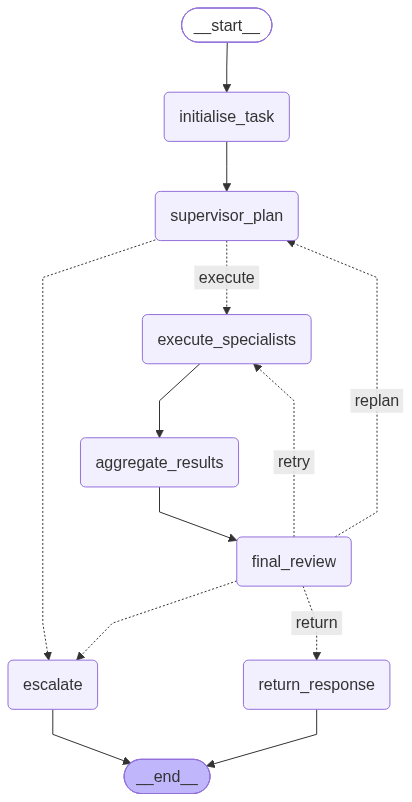

In [114]:
graph = build_supervisor_graph()
graph

In [120]:
graph = build_supervisor_graph()

result = graph.invoke(
    {
        "user_id": "user_001",
        "user_request": (
            "Write an essay on the role of Iron Man in Avengers: Endgame (800 - 1000 words)"
        ),
    }
)

assert result["status"] == "completed", {
    "status": result.get("status"),
    "error": result.get("error"),
    "escalation_reason": result.get("escalation_reason"),
    "final_review": result.get("final_review"),
    "final_answer": result.get("final_answer"),
}

assert result["error"] is None
assert result["escalation_reason"] is None
assert result["final_answer"] is not None
assert isinstance(result["final_answer"], str)
assert len(result["final_answer"]) >= 100

final_review_ = result["final_review"]

assert final_review_ is not None
assert final_review_["passed"] is True
assert final_review_["action"] == "return"
assert 0.0 <= final_review_["score"] <= 1.0

# assert "monday" in result["final_answer"].lower() or "wrike" in result["final_answer"].lower() or "clickup" in result["final_answer"].lower()

print(result["final_answer"])

SEARCH QUERY (34 chars):
Iron Man role in Avengers: Endgame
The Marvel Cinematic Universe has been graced with numerous iconic characters, but few have had as profound an impact as Iron Man, aka Tony Stark. As a founding member of the Avengers, Iron Man has consistently demonstrated his unwavering dedication to protecting the world from threats both human and supernatural. In Avengers: Endgame, Iron Man plays a pivotal role in the team's efforts to defeat the Mad Titan, Thanos, and restore balance to the universe. This essay will delve into the significance of Iron Man's character, his background, and his crucial actions in Avengers: Endgame, ultimately highlighting his lasting impact on the Marvel Cinematic Universe. Iron Man, portrayed by Robert Downey Jr., is a central figure in the Marvel Cinematic Universe, and his influence on the team's dynamics and overall storyline cannot be overstated. Throughout the movie, Iron Man's character undergoes significant development, as he confron

In [121]:
print(result['final_answer'])

The Marvel Cinematic Universe has been graced with numerous iconic characters, but few have had as profound an impact as Iron Man, aka Tony Stark. As a founding member of the Avengers, Iron Man has consistently demonstrated his unwavering dedication to protecting the world from threats both human and supernatural. In Avengers: Endgame, Iron Man plays a pivotal role in the team's efforts to defeat the Mad Titan, Thanos, and restore balance to the universe. This essay will delve into the significance of Iron Man's character, his background, and his crucial actions in Avengers: Endgame, ultimately highlighting his lasting impact on the Marvel Cinematic Universe. Iron Man, portrayed by Robert Downey Jr., is a central figure in the Marvel Cinematic Universe, and his influence on the team's dynamics and overall storyline cannot be overstated. Throughout the movie, Iron Man's character undergoes significant development, as he confronts the consequences of his past actions and the weight of hi